**NOTICE:**  
The U.S. Army Corps of Engineers, Risk Management Center (USACE-RMC) makes no guarantees about the results, or appropriateness of outputs, obtained from Numerics.

# 08. Time Series Analysis
The Numerics library provides a comprehensive `TimeSeries` class for working with time-indexed data. This class supports regular and irregular time intervals, statistical operations, transformations, and analysis methods essential for hydrological and environmental data.

## What You'll Learn

- Creating and manipulating TimeSeries objects
- Smoothing techniques (moving average, exponential, Gaussian)
- Block operations (annual max, monthly mean)
- Interpolation and resampling
- Trend analysis
- Seasonal decomposition
- Working with hydrologic data

## Real-World Applications

Streamflow analysis, climate data, water quality monitoring.

## Set Up

In [1]:
import pythonnet
pythonnet.load("coreclr")

import clr
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import math
from datetime import datetime

# Load Numerics DLL
dll_path = Path(r"C:\GIT\Numerics\Numerics\bin\Debug\net8.0\Numerics.dll")
clr.AddReference(str(dll_path))

from Numerics.Data import TimeSeries,  TimeInterval, BlockFunctionType,TimeSeriesDownload, SeriesOrdinate
from Numerics.Data.Statistics import Statistics, HypothesisTests
from Numerics.Distributions import GammaDistribution, Normal
from helper_functions import convert_to_dotnet_array
from System.Collections.Generic import List
from System import DateTime, Array, Double, Random

print("✓ Setup complete")

✓ Setup complete


## Helper Functions
We define some helper functions to switch between .NET, Python, and TimeSeries objects.

In [2]:
def ts_to_arrays(ts):
    dates = [o.Index for o in ts]
    values = [o.Value for o in ts]
    return np.array(dates), np.array(values)

def ts_to_python_time(dates):
    return [datetime(o.Year, o.Month, o.Day, o.Hour, o.Minute, o.Second) for o in dates]

## 1. Creating TimeSeries Objects
We will construct a regular daily time series and inspect its basic statistical properties. You can construct an empty time series; without or without a time interval (i.e. daily, monthly,etc). You can create a time series with date range of with start and end dates. Finally, you can contruct a time series from data. Below we construct one with data, giving it an interval, start date, and the generated data.

Base TimeSeries summary


,Metric,Value
0,Sample Size,40
1,Start Date,1/1/2020 12:00:00 AM
2,End Date,2/9/2020 12:00:00 AM
3,Mean,<bound method 'MeanValue'>
4,Std Dev,<bound method 'StandardDeviation'>
5,Min,<bound method 'MinValue'>
6,Max,<bound method 'MaxValue'>


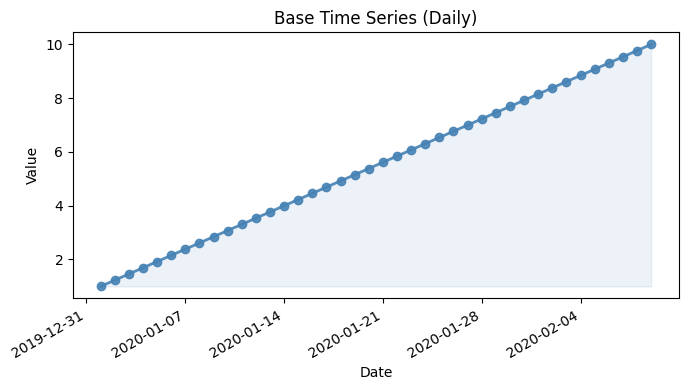

In [3]:
start = DateTime(2020, 1, 1)
values = np.linspace(1, 10, 40)
values_net = convert_to_dotnet_array(values.tolist())
ts = TimeSeries(TimeInterval.OneDay, start, values_net)
dates, vals = ts_to_arrays(ts)

ts_df = pd.DataFrame({'Metric':['Sample Size','Start Date','End Date','Mean','Std Dev','Min','Max'],'Value':
                      [len(ts),ts.StartDate,ts.EndDate,ts.MeanValue,ts.StandardDeviation,ts.MinValue,ts.MaxValue]})
print('Base TimeSeries summary')
display(ts_df)

# Convert to Python for plotting
py_ts = ts_to_python_time(dates)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(py_ts, vals, color='steelblue', linewidth=2, marker="o", alpha=0.9)
ax.fill_between(py_ts, vals, np.min(vals), color='steelblue', alpha=0.10)
ax.set_title("Base Time Series (Daily)")
ax.set_xlabel("Date")
ax.set_ylabel("Value")
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Acessing Data
Acessing the data in a `TimeSeries` object is similar to how you access information in an array.

In [4]:
ts =  TimeSeries(TimeInterval.OneDay, DateTime(2024, 1, 1), convert_to_dotnet_array([10.0, 15.0, 20.0, 25.0, 30.0 ]))

# Access by index
value = ts[2].Value;              # 20.0
date = ts[2].Index                # 2024-01-03

# Access by date
queryDate = DateTime(2024, 1, 3)
idx = ts.IndexesToList().IndexOf(queryDate)

if idx >= 0:
    ord_ = ts[idx]  # SeriesOrdinate
    print(f"Flow on {queryDate.ToString('yyyy-MM-dd')}: {ord_.Value:.1f}")
else:
    print(f"No flow value found for {queryDate.ToString('yyyy-MM-dd')}")

# Properties
count = ts.Count
firstDate = ts.StartDate
lastDate = ts.EndDate
values = ts.ValuesToArray()

Flow on 2024-01-03: 20.0


### Basic Arithmetic, Operations on Subsets, and Transformations

In [5]:
ts = TimeSeries(TimeInterval.OneDay, DateTime(2024, 1, 1), convert_to_dotnet_array([ 10.0, 15.0, 20.0, 25.0, 30.0 ]))

# Add constant to all values
ts.Add(5.0)                    # Now: 15, 20, 25, 30, 35

# Subtract constant
ts.Subtract(3.0)               # Now: 12, 17, 22, 27, 32

# Multiply by constant
ts.Multiply(2.0)               # Now: 24, 34, 44, 54, 64

# Divide by constant
ts.Divide(2.0)                 # Back to: 12, 17, 22, 27, 32

print("Transformed values:")
for ord_ in ts:
    print(f"{ord_.Index.ToString('yyyy-MM-dd')}: {ord_.Value:.1f}")

# Apply operations to specific indexes
indexes = List[int]()
indexes.Add(0)
indexes.Add(2)
indexes.Add(4)

ts.Add(10.0, indexes)          # Add 10 to selected values only
ts.Multiply(1.5, indexes)      # Multiply selected values by 1.5

ts = TimeSeries(TimeInterval.OneDay, DateTime(2024, 1, 1), convert_to_dotnet_array([ 10.0, 15.0, 20.0, 25.0, 30.0 ]))

# Absolute value
ts.AbsoluteValue()

# Exponentiation
ts.Exponentiate(2.0)           # Square all values

# Logarithm
ts.LogTransform(baseValue=10) # Log10 transform

# Standardize (z-score)
ts.Standardize()               # (x - mu) / sigma

# Inverse
ts.Inverse()                   # 1 / x

Transformed values:
2024-01-01: 12.0
2024-01-02: 17.0
2024-01-03: 22.0
2024-01-04: 27.0
2024-01-05: 32.0


## 2. Cumulative Sum and Differencing
The difference operator $\nabla$ removes trends from a time series. The first difference at lag $d$ is: $\nabla^d x_t = x_t - x_{t-d}$.
First differencing ($d = 1$) removes a linear trend. Applying the operator twice, $\nabla^2 x_t = \nabla(\nabla x_t)$, removes a quadratic trend. Seasonal differencing uses a lag equal to the seasonal period. For example, d = 12, for monthly data with an annual cycle removes the seasonal component directly.

In [6]:
dailyRainfall = convert_to_dotnet_array([ 0.5, 1.2, 0.8, 0.0, 2.1, 1.5, 0.5, 1.2, 0.8, 0.0, 2.1, 1.5, 0.5 ])
rainfall = TimeSeries(TimeInterval.OneDay, DateTime(2024, 1, 1), dailyRainfall)

# Compute cumulative rainfall
cumulative = rainfall.CumulativeSum()

print("Day | Daily | Cumulative")
for i in range(rainfall.Count):
    print(f"{i + 1,3} | {rainfall[i].Value:5.1f} | {cumulative[i].Value:10.1f}")

# First difference 
diff1 = rainfall.Difference(lag=1, differences=1)

# Second difference
diff2 = rainfall.Difference(lag=1, differences=2)

# Seasonal difference (e.g., monthly lag for annual pattern)
seasonalDiff = rainfall.Difference(lag=12, differences=1)

print("Original | First Diff | Second Diff")
for i in range(min(5, ts.Count)):
    orig = ts[i].Value if i < ts.Count else math.nan
    d1 = diff1[i].Value if i < diff1.Count else math.nan
    d2 = diff2[i].Value if i < diff2.Count else math.nan

    print(f"{orig:8.2f} | {d1:10.2f} | {d2:11.2f}")

Day | Daily | Cumulative
(1, 3) |   0.5 |        0.5
(2, 3) |   1.2 |        1.7
(3, 3) |   0.8 |        2.5
(4, 3) |   0.0 |        2.5
(5, 3) |   2.1 |        4.6
(6, 3) |   1.5 |        6.1
(7, 3) |   0.5 |        6.6
(8, 3) |   1.2 |        7.8
(9, 3) |   0.8 |        8.6
(10, 3) |   0.0 |        8.6
(11, 3) |   2.1 |       10.7
(12, 3) |   1.5 |       12.2
(13, 3) |   0.5 |       12.7
Original | First Diff | Second Diff
   -0.70 |       0.70 |       -1.10
   -2.00 |      -0.40 |       -0.40
    6.16 |      -0.80 |        2.90
    1.48 |       2.10 |       -2.70
    0.91 |      -0.60 |       -0.40


## 3. Smoothing
We will explore 2 ways we can smooth noisy data using simple moving averages. A simple moving average (SMA) of period m smooths a time series by replacing each value with the average of the preceding m observations.

$$
\text{SMA}_t = \frac{1}{m}\sum_{j=0}^{m-1} x_{t-j}
$$


The moving average acts as a low-pass filter: it attenuates fluctuations with period shorter than m while preserving longer-term trends.The output series has n - m + 1 values because the first m - 1 observations do not have a full window. The Numerics library provides built-in MovingAverage and MovingSum methods that use a sliding window for O(n) efficiency.

1. **Moving Average:** Apply a rolling mean to reduce high-frequency variability while preserving trend.
2. **Moving Sum:** Compute rolling accumulation over a fixed window, useful for volume-based metrics.



Smoothing summary


,Metric,Value
0,Original Mean,43.162949
1,Smoothed Mean (MA),43.164698
2,First MA Value,42.176605
3,First Moving Sum,126.529816


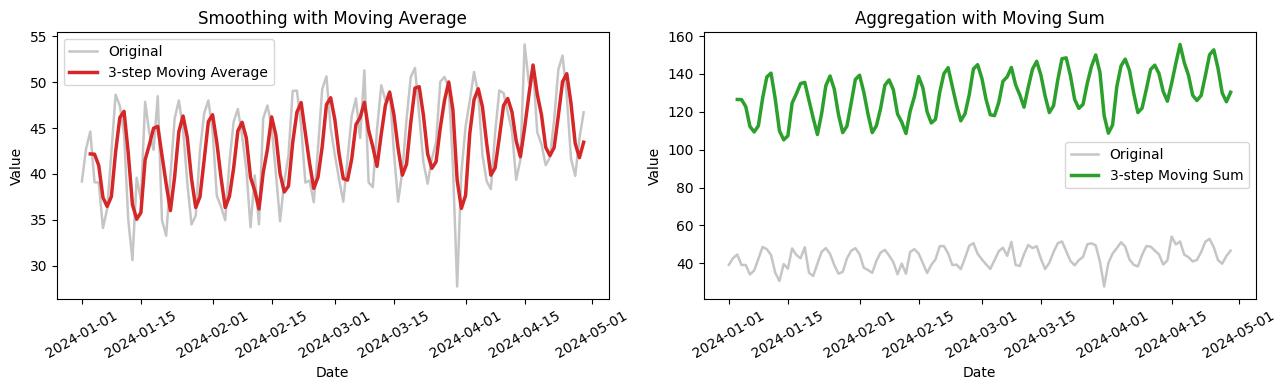

In [7]:
# Create synthetic data with weekly cycle and spikes
np.random.seed(12)
n = 120
t = np.arange(n)
baseline = 40 + 0.05*t
weekly = 6*np.sin(2*np.pi*t/7)
noise = list(Normal(0,1.8).GenerateRandomValues(n, 789)) 

values = baseline + weekly + noise
values[[18, 42, 67, 89, 105]] += np.array([10, -8, 12, -10, 9])  # anomalies

start = DateTime(2024, 1, 1)
ts = TimeSeries(TimeInterval.OneDay, start, convert_to_dotnet_array(values.tolist()))
dates, vals = ts_to_arrays(ts)
py_ts = ts_to_python_time(dates)

# Calculate 3 day moving average
ma = ts.MovingAverage(period=3)
ma_dates, ma_vals = ts_to_arrays(ma)
py_ma_dates = ts_to_python_time(ma_dates)

# Calculate 3 day moving sum
ms = ts.MovingSum(period=3)
ms_dates, ms_vals = ts_to_arrays(ms)
py_ms_dates = ts_to_python_time(ms_dates)

smooth_df = pd.DataFrame({'Metric':['Original Mean','Smoothed Mean (MA)','First MA Value','First Moving Sum'],'Value':
                          [vals.mean(),ma_vals.mean(),ma_vals[0],ms_vals[0]]})
print('Smoothing summary')
display(smooth_df)

# Graph!
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=False)
# Left: MA
axes[0].plot(py_ts, vals, color="gray", alpha=0.45, linewidth=1.8, label="Original")
axes[0].plot(py_ma_dates, ma_vals, color="#d62728", linewidth=2.5, label="3-step Moving Average")
axes[0].set_title("Smoothing with Moving Average")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Value")
axes[0].legend()

# Right: MS
axes[1].plot(py_ts, vals, color="gray", alpha=0.45, linewidth=1.8, label="Original")
axes[1].plot(py_ms_dates, ms_vals, color="#2ca02c", linewidth=2.5, label="3-step Moving Sum")
axes[1].set_title("Aggregation with Moving Sum")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Value")
axes[1].legend()

for ax in axes:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 4. Block Operations

The Numerics library can aggregate a time series into annual, monthly, or quarterly blocks using a specified function (minimum, maximum, average, or sum). This is essential for extracting annual maxima for flood frequency analysis, computing monthly means, or aggregating sub-daily data.

Block methods support optional smoothing before aggregation.

Calendar year maxima


,Year Index,Annual Max
0,1,18.732
1,2,20.767
2,3,22.270


Water year maxima


,Water Year Index,Annual Max
0,1,18.732
1,2,20.767
2,3,22.270


Monthly peaks


,Month Index,Monthly Peak
0,1,15.135
1,2,16.348
2,3,12.288
3,4,15.875
4,5,18.218
5,6,11.471
6,7,18.732
7,8,16.423
8,9,16.240
9,10,11.565


Quarterly peaks


,Quarterly Index,Qaurterly Peak
0,1,16.348
1,2,18.218
2,3,18.732
3,4,17.575
4,5,19.153
5,6,17.722
6,7,20.767
7,8,14.527
8,9,15.105
9,10,16.442


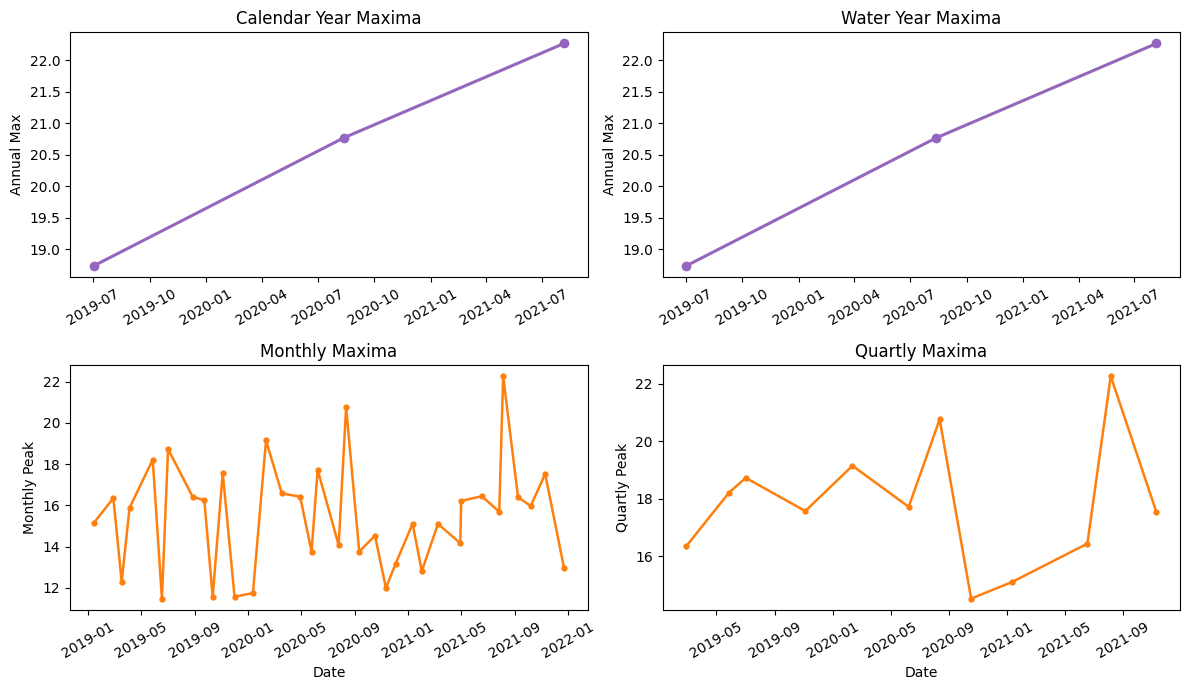

In [8]:
start = DateTime(2019, 1, 1)
values = GammaDistribution(2,3).GenerateRandomValues(1095,123)
daily = TimeSeries(TimeInterval.OneDay, start, values)

# Annual maximum flow (calendar year: Jan-Dec)
annual_max = daily.CalendarYearSeries(blockFunction=BlockFunctionType.Maximum)
annual_dates, annual_vals = ts_to_arrays(annual_max)
py_annual_dates = ts_to_python_time(annual_dates)

# Water year maximum (Oct-Sep, standard in US hydrology)
water_year_max = daily.CalendarYearSeries(startMonth=10, blockFunction=BlockFunctionType.Maximum)
water_dates, water_vals = ts_to_arrays(water_year_max)
py_water_dates = ts_to_python_time(water_dates)

monthly_max = daily.MonthlySeries(BlockFunctionType.Maximum)
mm_dates, mm_vals = ts_to_arrays(monthly_max)
py_mm_dates = ts_to_python_time(mm_dates)

quarterly_max = daily.QuarterlySeries(BlockFunctionType.Maximum)
q_dates, q_vals = ts_to_arrays(quarterly_max)
py_q_dates = ts_to_python_time(q_dates)

annual_tbl = pd.DataFrame({'Year Index': np.arange(1, len(annual_vals)+1), 'Annual Max': np.round(annual_vals, 3)})
water_tbl = pd.DataFrame({'Water Year Index': np.arange(1, len(water_vals)+1), 'Annual Max': np.round(water_vals, 3)})
monthly_tbl = pd.DataFrame({'Month Index': np.arange(1, len(mm_vals)+1), 'Monthly Peak': np.round(mm_vals, 3)})
quartley_tbl = pd.DataFrame({'Quarterly Index': np.arange(1, len(q_vals)+1), 'Qaurterly Peak': np.round(q_vals, 3)})
print('Calendar year maxima')
display(annual_tbl)
print('Water year maxima')
display(water_tbl)
print('Monthly peaks')
display(monthly_tbl)
print('Quarterly peaks')
display(quartley_tbl)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=False)

axes[0,0].plot(py_annual_dates, annual_vals, marker="o", linewidth=2.2, color="#9467bd")
axes[0,0].set_title("Calendar Year Maxima")
axes[0,0].set_ylabel("Annual Max")
axes[0,0].tick_params(axis="x", rotation=30)

axes[0,1].plot(py_water_dates, water_vals, marker="o", linewidth=2.2, color="#9467bd")
axes[0,1].set_title("Water Year Maxima")
axes[0,1].set_ylabel("Annual Max")
axes[0,1].tick_params(axis="x", rotation=30)


axes[1,0].plot(py_mm_dates, mm_vals, marker="o", markersize=3.5, linewidth=1.8, color="#ff7f0e")
axes[1,0].set_title("Monthly Maxima")
axes[1,0].set_xlabel("Date")
axes[1,0].set_ylabel("Monthly Peak")
axes[1,0].tick_params(axis="x", rotation=30)

axes[1,1].plot(py_q_dates, q_vals, marker="o", markersize=3.5, linewidth=1.8, color="#ff7f0e")
axes[1,1].set_title("Quartly Maxima")
axes[1,1].set_xlabel("Date")
axes[1,1].set_ylabel("Quartly Peak")
axes[1,1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### Peaks Over Threshold
Extract independent peaks that exceed a threshold, with a minimum separation between events.

In [9]:
# Find flood peaks exceeding 20 cfs, at least 7 days apart
peaks = daily.PeaksOverThresholdSeries(threshold= 20.0, minStepsBetweenEvents= 7)
dates, values = ts_to_arrays(peaks)
tbl = pd.DataFrame({'Index': np.arange(1, len(values)+1), 'Peak': np.round(values, 3)})
display(tbl)

,Index,Peak
0,1,20.767
1,2,22.270


## 5. Interpolation
Interpolate short gaps in the time series while preserving surrounding trends. The TimeSeries object in Numerics has an interpolation option in addition to a seperate Interpolation class under the Data namespace of Numerics. This other class includes linear, cubic spline, polynomial, and bilinear interpolation methods. The TimeSeries interpolation method below uses linear interpolation.

You can set a specificed maximum so that only gaps smaller will be filled: `InterpolateMissingData(maxNumberOfMissing=3)`

Interpolation summary


,Metric,Value
0,Missing before,0
1,Missing after,0


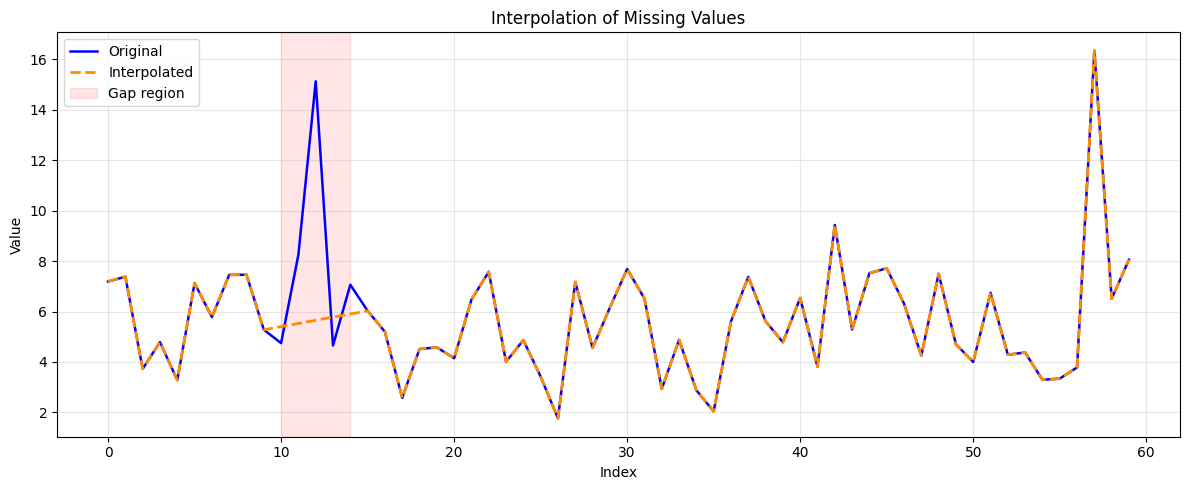

In [10]:
start = DateTime(2019, 1, 1)
values = GammaDistribution(2,3).GenerateRandomValues(60,123)
daily = TimeSeries(TimeInterval.OneDay, start, values)
_, daily_vals = ts_to_arrays(daily)

daily_vals_gap = daily_vals

daily_vals_gap[10:15] = np.nan
daily_vals_gap = convert_to_dotnet_array(daily_vals_gap.tolist())

ts_gap = TimeSeries(TimeInterval.OneDay, start, daily_vals_gap)
missing_before = ts.NumberOfMissingValues()
ts_gap.InterpolateMissingData(maxNumberOfMissing=10)
missing_after = sum(np.isnan(o.Value) for o in ts_gap)

interp_dates, interp_vals = ts_to_arrays(ts_gap)
py_interp_dates = ts_to_python_time(interp_dates)
interp_df = pd.DataFrame({'Metric':['Missing before','Missing after'],'Value':[missing_before, missing_after]})
print('Interpolation summary')
display(interp_df)

plt.figure(figsize=(12, 5))
plt.plot(np.arange(len(daily_vals)), values, color='blue', linewidth=1.8, label='Original')
plt.plot(np.arange(len(interp_vals)), interp_vals, color='darkorange', linestyle='--', linewidth=2, label='Interpolated')
plt.axvspan(10, 14, color="red", alpha=0.10, label="Gap region")
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Interpolation of Missing Values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 6. Time Interval Conversion
Convert between time intervals by aggregation (downsampling) or interpolation (upsampling):

When downsampling, `average: true` computes the block mean and `average: false` computes the `block sum`. When upsampling, `average: true` uses linear interpolation and `average: false` disaggregates proportionally.

Hourly resampling summary


,Metric,Value
0,Hourly Count,1417.000000
1,Hourly Mean,5.742971
2,Hourly Std,2.112484


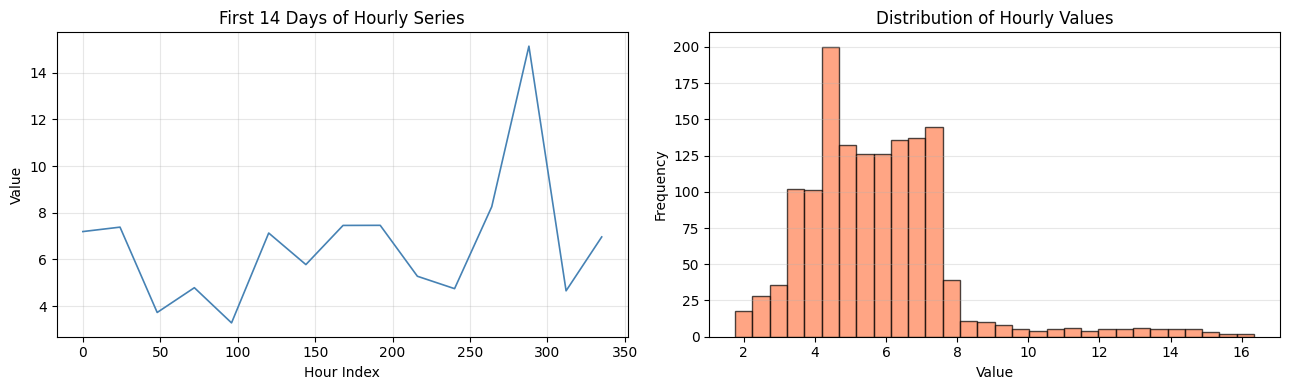

In [11]:
hourly = daily.ConvertTimeInterval(
    TimeInterval.OneHour,
    average=True
)

_, hourly_vals = ts_to_arrays(hourly)
resample_df = pd.DataFrame({'Metric':['Hourly Count','Hourly Mean','Hourly Std'],'Value':
                            [len(hourly_vals), hourly_vals.mean(), hourly_vals.std()]})
print('Hourly resampling summary')
display(resample_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hourly_vals[:24*14], linewidth=1.2, color='steelblue')
axes[0].set_title('First 14 Days of Hourly Series')
axes[0].set_xlabel('Hour Index')
axes[0].set_ylabel('Value')
axes[0].grid(True, alpha=0.3)

axes[1].hist(hourly_vals, bins=30, color='coral', alpha=0.7, edgecolor='black')
axes[1].set_title('Distribution of Hourly Values')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

## 7. Resampling
**Block Bootstrap:** The block bootstrap preserves temporal dependence by resampling contiguous blocks rather than individual observations. Given a block size, b, the method randomly selects blocks of b consecutive values (with replacement) and concatenates them. Unlike the standard bootstrap (which destroys autocorrelation), the block bootstrap retains the short-range dependence structure within each block.

**k-Nearest Neighbors** The k-nearest neighbors (k-NN) resampling method generates synthetic time series that preserve the multivariate dependence structure. At each step, it finds the k nearest neighbors of the current state in the historical record (using Euclidean distance on standardized values) and randomly selects one as the next value:

In [12]:
# Generate a 1000-step synthetic series preserving 30-day temporal structure
resampled = ts.ResampleWithBlockBootstrap(timeSteps= 1000, blockSize= 30, seed= 42)

# Generate synthetic series using 5-nearest neighbors
synthetic = ts.ResampleWithKNN(timeSteps= 500, k= 5, seed= 42)

# COME BACK HERE TO ADD MORE

## 8. USGS Data Download Integration
Download observed streamflow data and apply immediate statistical analysis. We will plot this data in the next section.

In [13]:
# Site number for Mississippi River at St. Louis, MO
site = "07010000"
# Check to see if device is connected to the internet 
if TimeSeriesDownload.IsConnectedToInternet:
    task = TimeSeriesDownload.FromUSGS(site)
    result = task.Result
    ts = result.Item1
else:
    ts = None
    print("No internet connection detected. Skipping USGS download.")

if ts is not None:
    _, q_vals = ts_to_arrays(ts)
    # Check for NaN values
    valid = q_vals[~np.isnan(q_vals)]
    usgs_df = pd.DataFrame({'Metric':['USGS Sample Size','Valid Samples','Mean Flow','Peak Flow'],'Value':
                            [len(q_vals),len(valid),np.mean(valid),np.max(valid)]})
    print('USGS download summary')
    display(usgs_df)

    # Calculate monthly peaks
    monthly_max = ts.MonthlySeries(BlockFunctionType.Maximum)
    mm_dates, mm_vals = ts_to_arrays(monthly_max)
    monthly_df = pd.DataFrame({'Month Index': np.arange(1, len(mm_vals)+1), 'Monthly Peak': np.round(mm_vals, 3)})
    print('Monthly peaks from downloaded series')
    display(monthly_df)
else:
    print('USGS download unavailable in this environment.')

USGS download summary


,Metric,Value
0,USGS Sample Size,6.033500e+04
1,Valid Samples,5.996700e+04
2,Mean Flow,1.906636e+05
3,Peak Flow,1.050000e+06


Monthly peaks from downloaded series


,Month Index,Monthly Peak
0,1,41400.0
1,2,170000.0
2,3,257000.0
3,4,353000.0
4,5,466000.0
...,...,...
1966,1967,94800.0
1967,1968,88000.0
1968,1969,134000.0
1969,1970,115000.0


## 9. Plotting Time Series
Using out USGS data we will plot it to inspect trend, seasonality, variability, and anomalies. This is important to check before fitting models.
This section overlays raw and transformed series for visual diagnostics.

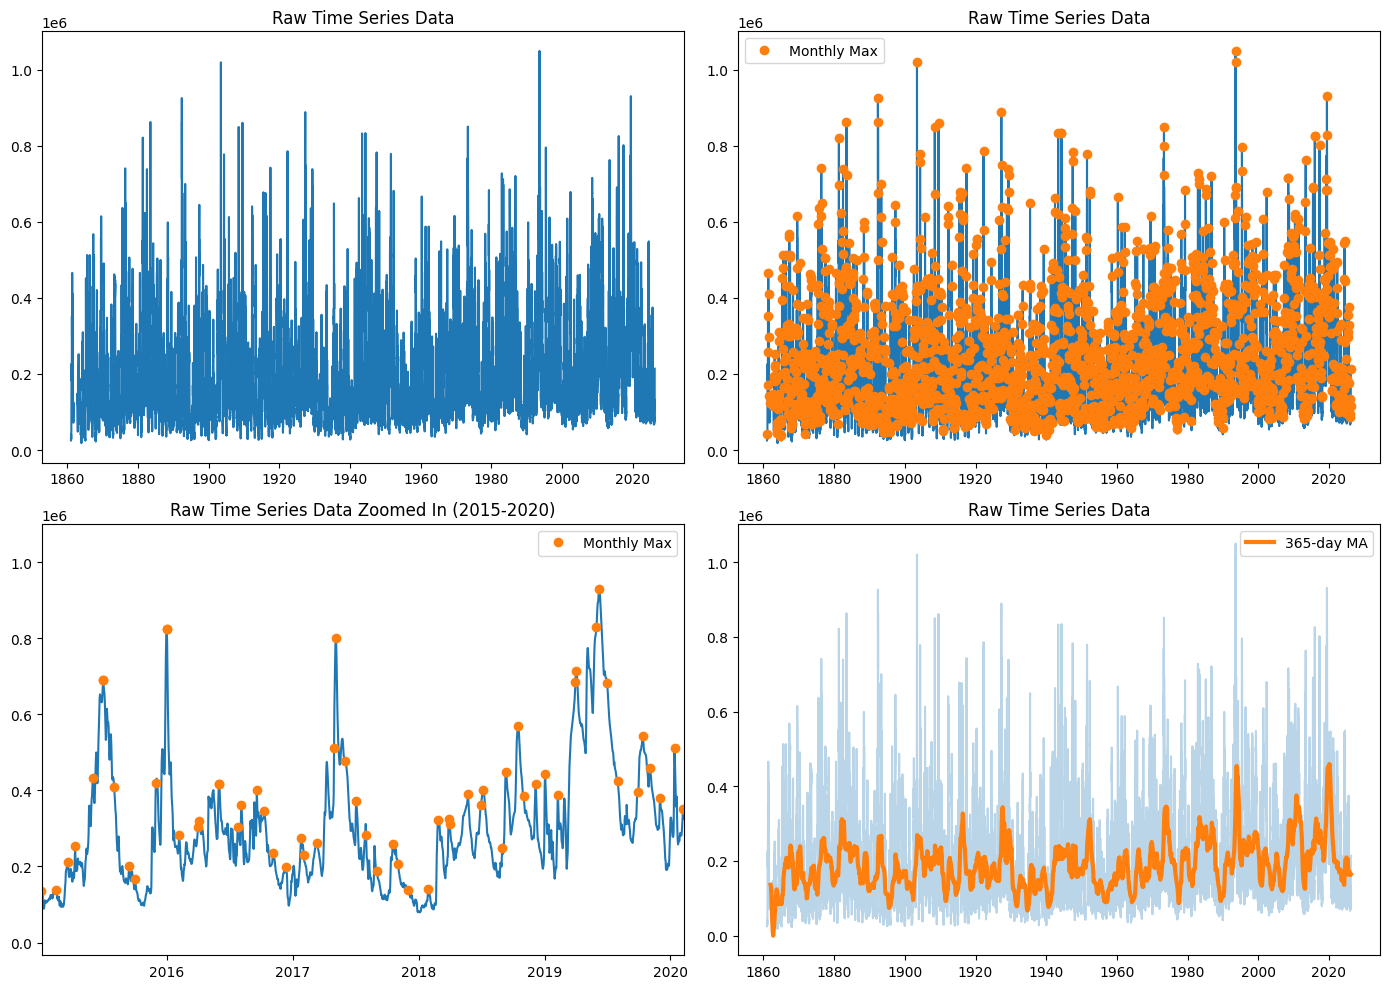

In [14]:
# Raw data
dates, vals = ts_to_arrays(ts)
# Convert .NET DateTime to Python datetime
py_dates = ts_to_python_time(dates)
py_mm_dates = ts_to_python_time(mm_dates)

# Moving average over the past year
ma = ts.MovingAverage(period=365)

# Convert time series object to arrays for plotting
ma_dates, ma_vals = ts_to_arrays(ma)
# Convert .NET DateTime to Python datetime
py_ma_dates = [datetime(o.Year, o.Month, o.Day, o.Hour, o.Minute, o.Second) for o in ma_dates]  

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(py_dates, vals)
axes[0,0].set_title("Raw Time Series Data")

plt.sca(axes[0,1])
axes[0,1].plot(py_dates, vals)
axes[0,1].plot(py_mm_dates, mm_vals, "o", label="Monthly Max")
axes[0,1].set_title("Raw Time Series Data")
axes[0,1].legend()

plt.sca(axes[1,0])
axes[1,0].plot(py_dates, vals)
axes[1,0].plot(py_mm_dates, mm_vals, "o", label="Monthly Max")
axes[1,0].set_title("Raw Time Series Data Zoomed In (2015-2020)")
axes[1,0].set_xlim([datetime(2015,1,3), datetime(2020,2,9)])
axes[1,0].legend()

plt.sca(axes[1,1])
axes[1,1].plot(py_dates, vals, alpha=0.3)
axes[1,1].plot(py_ma_dates, ma_vals, linewidth=3, label ="365-day MA")
axes[1,1].set_title("Raw Time Series Data")
axes[1,1].legend()

plt.tight_layout()
plt.show()


## 10. Examples
### Example 1: Annual Peak Flow Analysis

In [15]:
# # Monthly flow data
# monthlyFlow =[125, 135, 180, 220, 250, 280, 260, 230, 190, 150, 130, 120]
# flowData = TimeSeries(TimeInterval.OneMonth, DateTime(2024, 1, 1), convert_to_dotnet_array(monthlyFlow))

# print("Monthly Streamflow Analysis")
# print("=" * 51)

# # Find annual peak
# peakFlow = flowData.MaxValue

# peakMonth = Array.IndexOf(convert_to_dotnet_array(monthlyFlow), peakFlow)+1

# print(f"Peak flow: {peakFlow:.0f} cfs")
# print(f"Peak month: Month {peakMonth}")

# # Compute seasonal statistics
# spring = monthlyFlow[2:5]  # MAM
# summer = monthlyFlow[5:8]  # JJA

# print(f"\nSeasonal Means:")
# print(f"  Spring (MAM): {sum(spring)/len(spring):.0f} cfs")
# print(f"  Summer (JJA): {sum(summer)/len(summer):.0f} cfs")

### Example 2: Trend Detection

In [16]:
annualPeaks = [1200, 1250, 1180, 1300, 1320, 1280, 1350, 1400, 1380, 1450]
years = [DateTime(y, 1, 1) for y in range(2015, 2025)]

peakSeries = TimeSeries(TimeInterval.OneYear)
for dt, val in zip(years, annualPeaks):
    peakSeries.Add(SeriesOrdinate[DateTime, float](dt, float(val)))

print("Annual Peak Flow Trend Analysis")
print("=" * 51)

# Linear regression for trend (least squares)
x = [float(i) for i in range(peakSeries.Count)]
y = list(peakSeries.ValuesToArray())

xMean = sum(x) / len(x)
yMean = sum(y) / len(y)

numerator = sum((xi - xMean) * (yi - yMean) for xi, yi in zip(x, y))
denominator = sum((xi - xMean) ** 2 for xi in x)
slope = numerator / denominator
intercept = yMean - slope * xMean

print(f"Trend: {slope:.1f} cfs/year")
print(f"Direction: {'Increasing' if slope > 0 else 'Decreasing'}")

# Mann-Kendall test for significance
mkStat = HypothesisTests.MannKendallTest(convert_to_dotnet_array(y))
print(f"Mann-Kendall statistic: {mkStat:.2f}")

if abs(mkStat) > 1.96:
    print("Trend is statistically significant (p < 0.05)")
else:
    print("Trend is not statistically significant")

Annual Peak Flow Trend Analysis
Trend: 26.5 cfs/year
Direction: Increasing
Mann-Kendall statistic: 0.00
Trend is not statistically significant


### Example 3: Seasonal Analysis

In [17]:
# Multi-year daily data
nYears = 3
daysPerYear = 365
random = Random(123)

dailyTemp = TimeSeries(TimeInterval.OneDay)

# Generate seasonal temperature pattern
for day in range(nYears * daysPerYear):
    # Sinusoidal pattern + noise
    seasonalTemp = 15 + 10 * np.sin(2 * np.pi * day / 365.0)
    noise = (random.NextDouble() - 0.5) * 4
    dailyTemp.Add(SeriesOrdinate[DateTime, float]( DateTime(2022, 1, 1).AddDays(day), seasonalTemp + noise))

print("Seasonal Temperature Analysis")
print("=" * 51)

# Compute monthly averages using built-in MonthlySeries
monthlyAvgSeries = dailyTemp.MonthlySeries(BlockFunctionType.Average)

print("\nDate       | Avg Temp (degC)")
print("-----------|-------------")
for ord in monthlyAvgSeries:
    print(f"{ord.Index.ToString('yyyy-MM')} | {ord.Value:13.1f}")

Seasonal Temperature Analysis

Date       | Avg Temp (degC)
-----------|-------------
2022-01 |          17.5
2022-02 |          21.8
2022-03 |          24.1
2022-04 |          24.4
2022-05 |          21.9
2022-06 |          17.5
2022-07 |          12.4
2022-08 |           8.0
2022-09 |           5.3
2022-10 |           5.3
2022-11 |           8.1
2022-12 |          12.6
2023-01 |          17.3
2023-02 |          22.3
2023-03 |          24.3
2023-04 |          24.2
2023-05 |          22.1
2023-06 |          17.8
2023-07 |          12.8
2023-08 |           8.2
2023-09 |           5.8
2023-10 |           5.2
2023-11 |           8.0
2023-12 |          12.4
2024-01 |          17.4
2024-02 |          22.2
2024-03 |          24.3
2024-04 |          24.6
2024-05 |          22.1
2024-06 |          17.2
2024-07 |          12.6
2024-08 |           8.0
2024-09 |           5.8
2024-10 |           5.3
2024-11 |           8.1
2024-12 |          12.5


# Summary

You've learned:

$\checkmark$ Creating and manipulating TimeSeries objects     
$\checkmark$ Smoothing: moving average, moving sum        
$\checkmark$ Block operations: annual max, monthly means      
$\checkmark$ Interpolation        
$\checkmark$ Resampling       
$\checkmark$ USGS Data Integration        
$\checkmark$ Plotting TimeSeries data     

## Key Takeaways

1. **Smoothing reduces noise** - Choose window based on application
2. **Block operations summarize** - Annual max for floods, monthly means for patterns
3. **Interpolation fills gaps** - Use appropriate method for data type
4. **Resampling:**

## Next Steps

- **02_distribution_fitting.ipynb** - Fit distributions to annual max series
- **07_statistics.ipynb** - Statistical tests on time series

## Exercise

1. Create a time series with seasonal pattern
2. Apply 3 different smoothing methods
3. Extract annual maximums
5. Which method best captures the signal...